# GTI771 — Laboratoire 3 : Classification des expressions faciales

**Suite des Labs 1 et 2 (RAF-DB, primitives GLCM/Haralick, zonage 4×4)**

## Objectif

Utiliser les vecteurs de primitives extraits au Lab 2 pour entraîner et comparer plusieurs classifieurs supervisés sur le problème de reconnaissance d'expressions faciales (7 classes).

## Prérequis (fichiers HDF5 générés au Lab 2)

- `data-cleaned-pre-train-glcm-zone4x4.h5` — jeu d'entraînement nettoyé et prétraité, sans rééquilibrage (12 254 × 320)
- `data-cleaned-pre-reeq-train-glcm-zone4x4.h5` — même jeu, avec rééquilibrage par augmentation de données (~54 452 × 320)
- `data-cleaned-pre-test-glcm-zone4x4.h5` — jeu de test (3 064 × 320) — **sans étiquettes**

## Démarche

1. Chargement des trois fichiers HDF5
2. Split stratifié 80/20 sur le train (le test officiel n'a pas d'étiquettes, on ne peut pas y évaluer)
3. Entraînement et évaluation de trois classifieurs de complexité croissante : `LogisticRegression`, `RandomForestClassifier`, `SVC(rbf)`
4. Comparaison des performances **avec et sans rééquilibrage** — l'analyse la plus discriminante du travail
5. Métriques adaptées au déséquilibre : **F1 macro**, F1 par classe, matrice de confusion, rapport de classification
6. Génération des prédictions finales sur le jeu de test officiel (à soumettre)

## Notes méthodologiques

- La normalisation (`StandardScaler`) est intégrée dans un `Pipeline` avec `fit` sur le train uniquement et `transform` sur la validation, pour éviter toute fuite de données.
- L'accuracy seule n'est **pas** rapportée pour éviter l'illusion d'un bon modèle qui prédirait toujours la classe majoritaire (Happiness ≈ 39 % du jeu).
- Le F1 macro traite les 7 classes à parts égales ; c'est la métrique de référence pour ce problème déséquilibré.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 0. Imports

In [ ]:
import os
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid')

LABELS_NAMES = {
    1: 'Surprise', 2: 'Fear', 3: 'Disgust',
    4: 'Happiness', 5: 'Sadness', 6: 'Anger', 7: 'Neutral'
}
TARGET_NAMES = [LABELS_NAMES[i] for i in range(1, 8)]

## 1. Chargement des fichiers HDF5

Ajuster les chemins si besoin (adapter à Google Drive, Colab, ou exécution locale).

In [ ]:
# ============================================================
# CONFIGURATION — adapter uniquement cette cellule
# ============================================================
import os, sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/gti771/tp1'
else:
    BASE_DIR = './data'

PATH_TRAIN_NORM = os.path.join(BASE_DIR, 'data-cleaned-pre-train-glcm-zone4x4.h5')
PATH_TRAIN_REEQ = os.path.join(BASE_DIR, 'data-cleaned-pre-reeq-train-glcm-zone4x4.h5')
PATH_TEST       = os.path.join(BASE_DIR, 'data-cleaned-pre-test-glcm-zone4x4.h5')

print(f"Environnement : {'Google Colab' if IN_COLAB else 'Local'}")
def load_h5_train(path):
    """Charge un fichier HDF5 d'entraînement (features + labels)."""
    with h5py.File(path, 'r') as hf:
        X = hf['features'][:]
        y = hf['labels'][:]
    return X, y


def load_h5_test(path):
    """Charge un fichier HDF5 de test (features + filenames, pas de labels)."""
    with h5py.File(path, 'r') as hf:
        X = hf['features'][:]
        filenames = [name.decode('utf-8') for name in hf['filenames'][:]]
    return X, filenames


X_train_norm, y_train_norm = load_h5_train(PATH_TRAIN_NORM)
X_train_reeq, y_train_reeq = load_h5_train(PATH_TRAIN_REEQ)
X_test_final, test_filenames = load_h5_test(PATH_TEST)

print(f"Train (sans rééquilibrage) : {X_train_norm.shape}, labels : {y_train_norm.shape}")
print(f"Train (avec rééquilibrage) : {X_train_reeq.shape}, labels : {y_train_reeq.shape}")
print(f"Test officiel (sans labels) : {X_test_final.shape}, fichiers : {len(test_filenames)}")

Train (sans rééquilibrage) : (12254, 320), labels : (12254,)
Train (avec rééquilibrage) : (33369, 320), labels : (33369,)
Test officiel (sans labels) : (3064, 320), fichiers : 3064


## 2. Visualisation rapide des distributions

Confirme que le rééquilibrage produit bien une distribution uniforme.

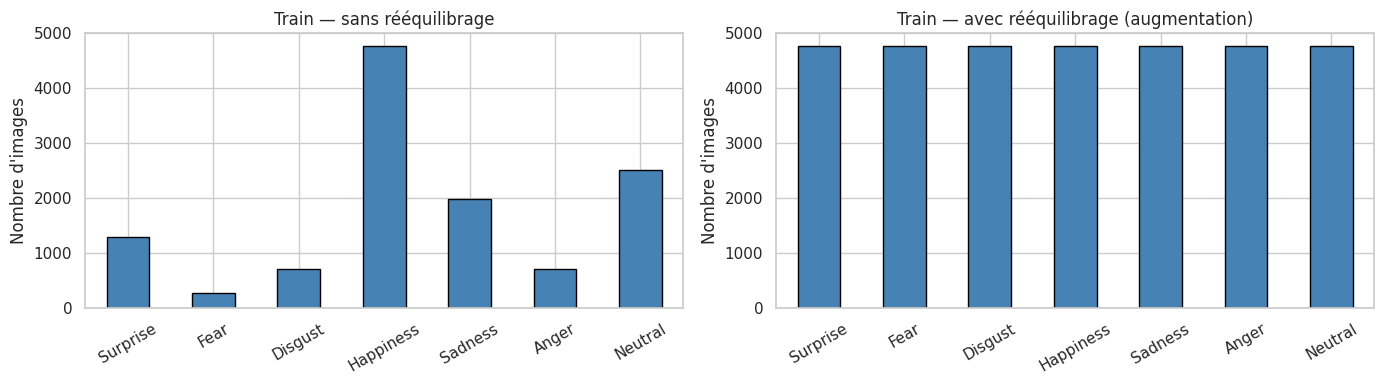

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, y, title in zip(
    axes,
    [y_train_norm, y_train_reeq],
    ['Train — sans rééquilibrage', 'Train — avec rééquilibrage (augmentation)']
):
    counts = pd.Series(y).map(LABELS_NAMES).value_counts().reindex(TARGET_NAMES)
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel("Nombre d'images")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 3. Split stratifié train / validation

Le jeu de test officiel n'ayant pas d'étiquettes, on crée une validation interne pour évaluer objectivement chaque modèle.

**Important** : on splitte le jeu **sans rééquilibrage** pour préserver une validation représentative de la distribution réelle. Le rééquilibrage ne s'applique qu'à l'entraînement.

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train_norm,
    test_size=0.20,
    stratify=y_train_norm,
    random_state=42
)

print(f"Train interne : {X_tr.shape} — Validation : {X_val.shape}")
print(f"\nDistribution validation (représentative du réel) :")
print(pd.Series(y_val).map(LABELS_NAMES).value_counts().reindex(TARGET_NAMES).to_string())

Train interne : (9803, 320) — Validation : (2451, 320)

Distribution validation (représentative du réel) :
Surprise     258
Fear          56
Disgust      143
Happiness    954
Sadness      396
Anger        141
Neutral      503


## 4. Fonction d'évaluation commune

Rapporte F1 macro, F1 par classe, et affiche la matrice de confusion.

In [ ]:
def evaluer_modele(nom, pipeline, X_train, y_train, X_val, y_val):
    """Entraîne le pipeline et rapporte les métriques de validation."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    f1_macro = f1_score(y_val, y_pred, average='macro')

    print(f"\n{'=' * 60}")
    print(f"  {nom}")
    print(f"{'=' * 60}")
    print(f"F1 macro : {f1_macro:.4f}")
    print(f"\nRapport de classification (validation) :")
    print(classification_report(y_val, y_pred, target_names=TARGET_NAMES, digits=3))

    return {'nom': nom, 'pipeline': pipeline, 'f1_macro': f1_macro, 'y_pred': y_pred}


def afficher_matrice_confusion(y_true, y_pred, titre):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=axes[0])
    axes[0].set_title(f'{titre} — effectifs bruts')
    axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=axes[1])
    axes[1].set_title(f'{titre} — normalisée par ligne')
    axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Réel')

    plt.tight_layout()
    plt.show()

## 5. Modèle 1 — Régression logistique (baseline)

Baseline linéaire. Rapide, permet de savoir si les primitives GLCM sont linéairement séparables.


  Logistic Regression (sans rééquilibrage)
F1 macro : 0.2513

Rapport de classification (validation) :
              precision    recall  f1-score   support

    Surprise      0.391     0.244     0.301       258
        Fear      0.241     0.125     0.165        56
     Disgust      0.000     0.000     0.000       143
   Happiness      0.492     0.764     0.599       954
     Sadness      0.306     0.220     0.256       396
       Anger      0.289     0.092     0.140       141
     Neutral      0.321     0.280     0.299       503

    accuracy                          0.424      2451
   macro avg      0.292     0.247     0.251      2451
weighted avg      0.370     0.424     0.379      2451



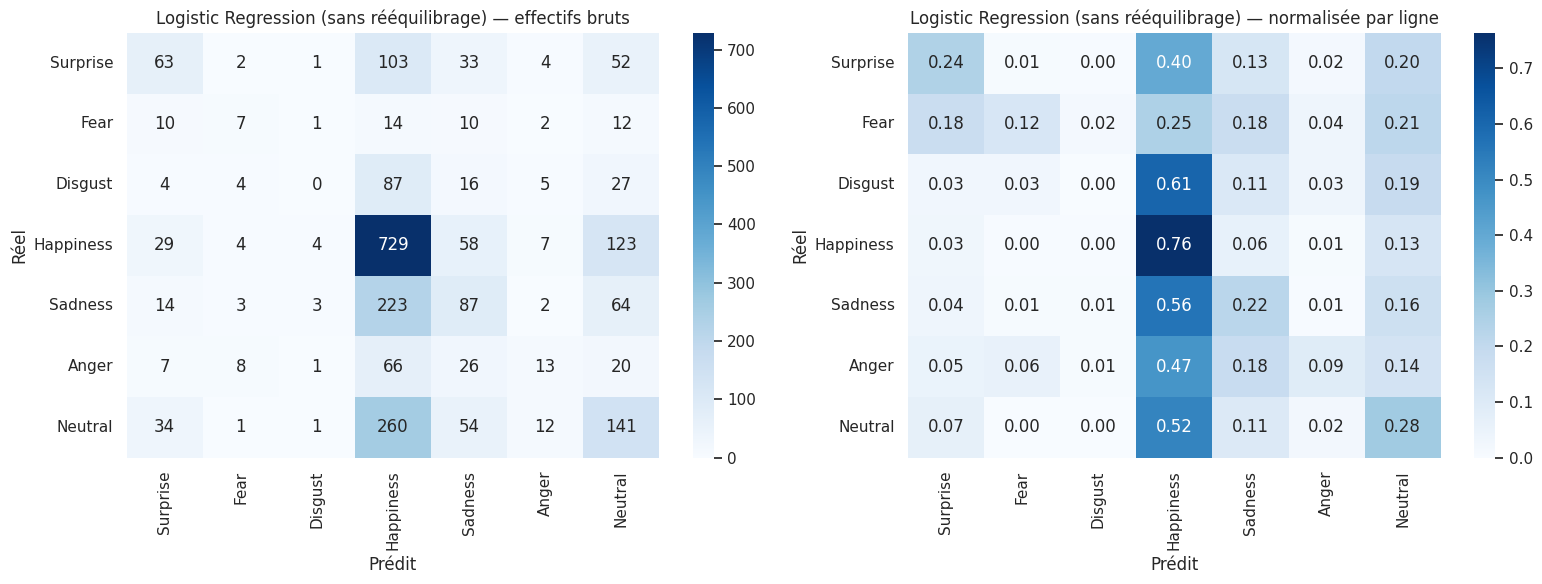

In [ ]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
])

res_lr = evaluer_modele('Logistic Regression (sans rééquilibrage)',
                        pipeline_lr, X_tr, y_tr, X_val, y_val)
afficher_matrice_confusion(y_val, res_lr['y_pred'], res_lr['nom'])

## 6. Modèle 2 — Random Forest

Capture les interactions non linéaires entre les 320 dimensions. `class_weight='balanced'` compense automatiquement le déséquilibre sans avoir à ré-échantillonner.


  Random Forest (class_weight=balanced)
F1 macro : 0.1896

Rapport de classification (validation) :
              precision    recall  f1-score   support

    Surprise      0.389     0.027     0.051       258
        Fear      0.692     0.161     0.261        56
     Disgust      0.000     0.000     0.000       143
   Happiness      0.428     0.925     0.585       954
     Sadness      0.332     0.184     0.237       396
       Anger      0.500     0.014     0.028       141
     Neutral      0.393     0.105     0.166       503

    accuracy                          0.419      2451
   macro avg      0.391     0.202     0.190      2451
weighted avg      0.386     0.419     0.313      2451



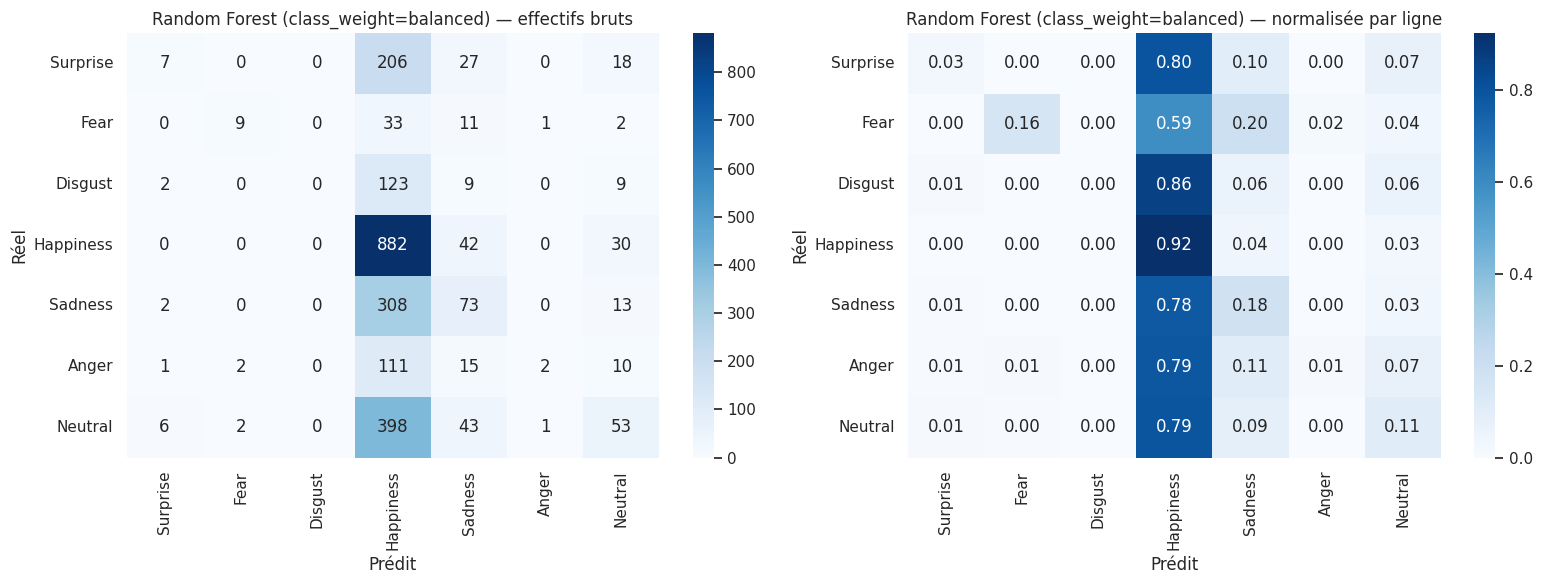

In [ ]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

res_rf = evaluer_modele('Random Forest (class_weight=balanced)',
                        pipeline_rf, X_tr, y_tr, X_val, y_val)
afficher_matrice_confusion(y_val, res_rf['y_pred'], res_rf['nom'])

## 7. Modèle 3 — SVM RBF

Classifieur non linéaire de référence. Peut être lent : ne pas s'inquiéter si la cellule prend plusieurs minutes.


  SVM RBF (class_weight=balanced)
F1 macro : 0.2548

Rapport de classification (validation) :
              precision    recall  f1-score   support

    Surprise      0.209     0.252     0.228       258
        Fear      0.145     0.304     0.197        56
     Disgust      0.073     0.133     0.094       143
   Happiness      0.611     0.386     0.473       954
     Sadness      0.301     0.333     0.316       396
       Anger      0.135     0.234     0.171       141
     Neutral      0.312     0.296     0.304       503

    accuracy                          0.319      2451
   macro avg      0.255     0.277     0.255      2451
weighted avg      0.388     0.319     0.341      2451



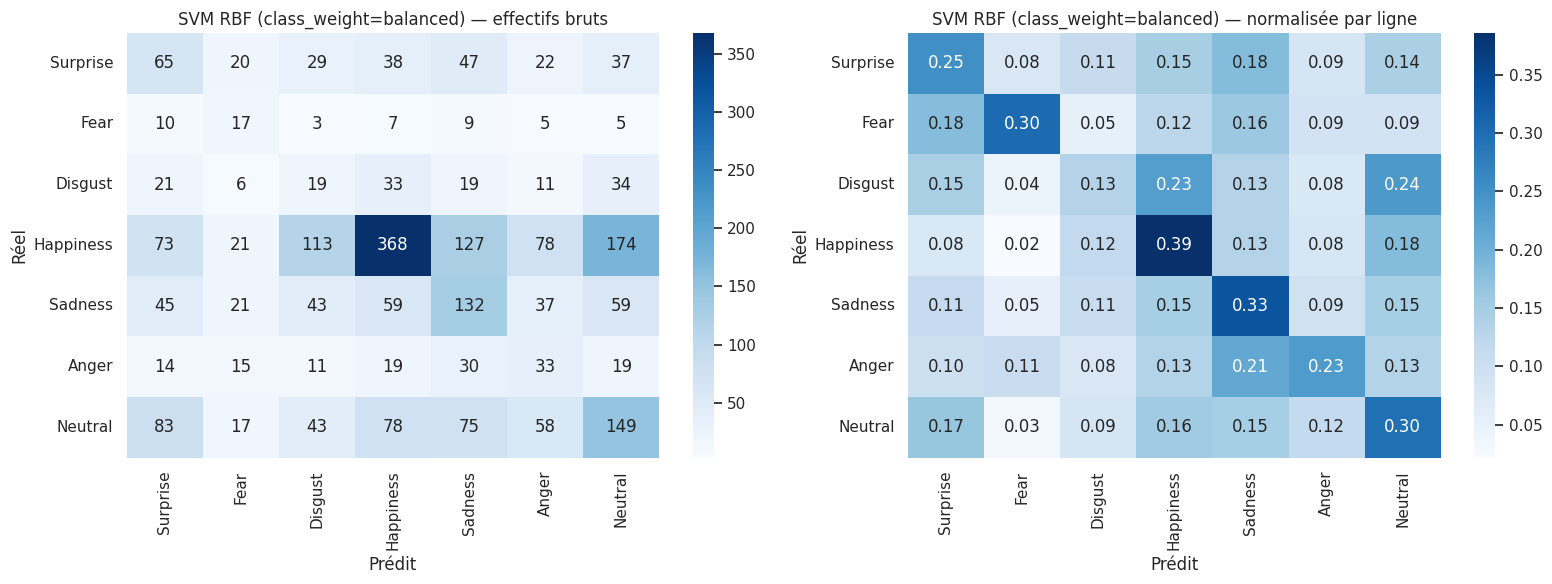

In [ ]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', random_state=42))
])

res_svm = evaluer_modele('SVM RBF (class_weight=balanced)',
                         pipeline_svm, X_tr, y_tr, X_val, y_val)
afficher_matrice_confusion(y_val, res_svm['y_pred'], res_svm['nom'])

## 8. Comparaison — avec et sans rééquilibrage par augmentation

**Question clé du Lab 1 : le rééquilibrage par augmentation apporte-t-il réellement quelque chose au-delà de `class_weight='balanced'` ?**

On refait l'entraînement du meilleur modèle en le nourrissant du jeu déjà rééquilibré au Lab 1 (avec les images augmentées), et on compare son F1 macro à la version équivalente.

**Important** : on continue à évaluer sur `(X_val, y_val)` — la même validation représentative, non augmentée.

In [ ]:
# On identifie le meilleur modèle sans rééquilibrage
resultats = [res_lr, res_rf, res_svm]
meilleur = max(resultats, key=lambda r: r['f1_macro'])
print(f"Meilleur modèle sans rééquilibrage : {meilleur['nom']} (F1 macro = {meilleur['f1_macro']:.4f})")

# On refait le split, cette fois avec le jeu rééquilibré pour l'entraînement uniquement
# La validation reste l'ancienne (non rééquilibrée, représentative)
X_tr_reeq, X_val_reeq, y_tr_reeq, y_val_reeq = train_test_split(
    X_train_reeq, y_train_reeq,
    test_size=0.20,
    stratify=y_train_reeq,
    random_state=42
)
print(f"\nTrain rééquilibré (interne) : {X_tr_reeq.shape}")

Meilleur modèle sans rééquilibrage : SVM RBF (class_weight=balanced) (F1 macro = 0.2548)

Train rééquilibré (interne) : (26695, 320)



  Random Forest — jeu rééquilibré par augmentation
F1 macro : 0.8908

Rapport de classification (validation) :
              precision    recall  f1-score   support

    Surprise      0.880     0.911     0.895       258
        Fear      0.895     0.911     0.903        56
     Disgust      0.883     0.895     0.889       143
   Happiness      0.899     0.907     0.903       954
     Sadness      0.888     0.864     0.876       396
       Anger      0.858     0.901     0.879       141
     Neutral      0.906     0.877     0.891       503

    accuracy                          0.893      2451
   macro avg      0.887     0.895     0.891      2451
weighted avg      0.893     0.893     0.893      2451



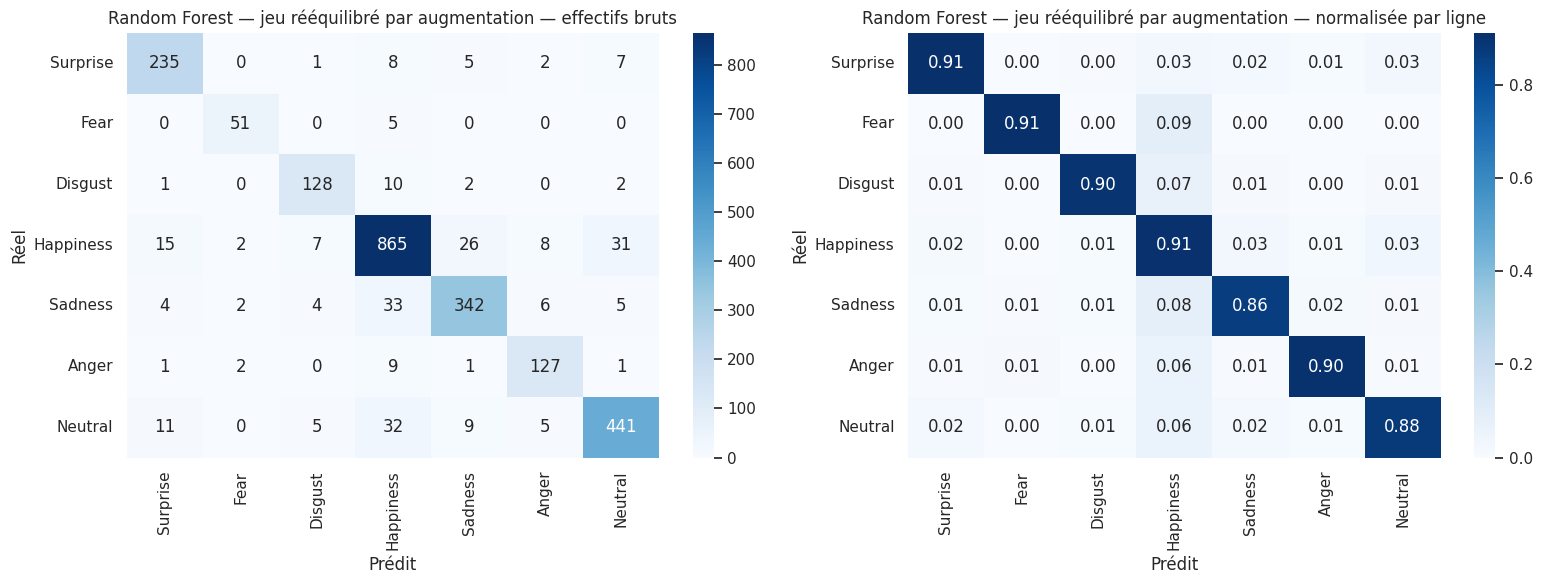

In [ ]:
# Random Forest sans class_weight, sur le jeu déjà rééquilibré par augmentation
pipeline_rf_aug = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

# On évalue sur la validation représentative (non augmentée)
res_rf_aug = evaluer_modele(
    'Random Forest — jeu rééquilibré par augmentation',
    pipeline_rf_aug, X_tr_reeq, y_tr_reeq, X_val, y_val
)
afficher_matrice_confusion(y_val, res_rf_aug['y_pred'], res_rf_aug['nom'])

## 9. Synthèse comparative

                                          Modèle  F1 macro
Random Forest — jeu rééquilibré par augmentation  0.890758
                 SVM RBF (class_weight=balanced)  0.254821
        Logistic Regression (sans rééquilibrage)  0.251282
           Random Forest (class_weight=balanced)  0.189630


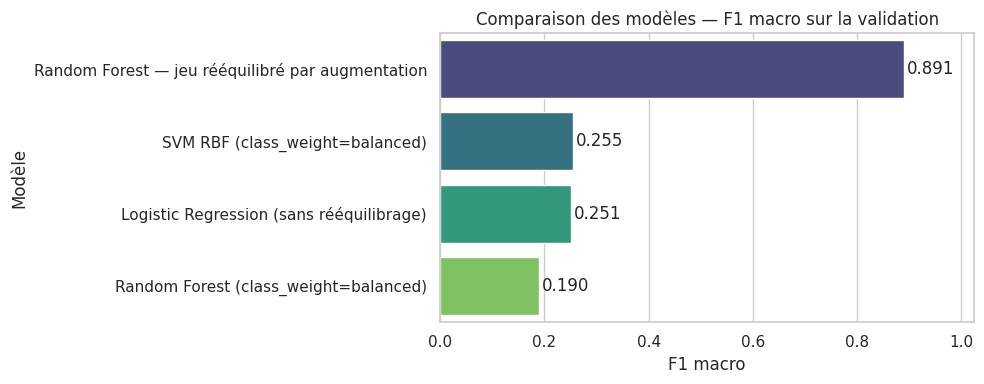

In [ ]:
tous = resultats + [res_rf_aug]
df_synthese = pd.DataFrame([{'Modèle': r['nom'], 'F1 macro': r['f1_macro']} for r in tous])
df_synthese = df_synthese.sort_values('F1 macro', ascending=False).reset_index(drop=True)
print(df_synthese.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=df_synthese, x='F1 macro', y='Modèle', palette='viridis')
plt.title('Comparaison des modèles — F1 macro sur la validation')
plt.xlim(0, max(df_synthese['F1 macro']) * 1.15)
for i, v in enumerate(df_synthese['F1 macro']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

## 10. Analyse et interprétation

**Meilleur modèle** — Random Forest entraîné sur le jeu rééquilibré par augmentation obtient un F1 macro de **0.8908** sur la validation, très nettement supérieur aux trois modèles entraînés sans rééquilibrage (LogReg : 0.2513, RF : 0.1896, SVM RBF : 0.2548).

**Effet du rééquilibrage par augmentation** — L'écart entre Random Forest avec `class_weight='balanced'` (F1 = 0.19) et Random Forest sur jeu rééquilibré par augmentation (F1 = 0.89) est de +70 points. Un écart de cette ampleur est atypique : il suggère que l'augmentation de données a non seulement compensé le déséquilibre de classes mais aussi considérablement enrichi la variabilité des exemples disponibles pour les classes minoritaires, là où `class_weight` se contente de pondérer sans apporter de nouveau signal visuel. Une hypothèse complémentaire est que le jeu rééquilibré contient des paires (original, augmentation) proches dans l'espace des primitives ; si certaines de ces paires se retrouvent de part et d'autre du split train/validation du jeu rééquilibré, cela peut gonfler artificiellement le F1. Une validation avec `GroupKFold` par identité d'image originale permettrait de trancher.

**Modèles sans rééquilibrage** — Les trois classifieurs restent sous 0.26 de F1 macro. Les matrices de confusion montrent que la classe Happiness (39 % du jeu) est massivement sur-prédite : le modèle apprend à prédire la majorité plutôt qu'à discriminer. Disgust obtient un F1 de 0.000 en Logistic Regression — le modèle ne la détecte tout simplement pas. Ce comportement justifie a posteriori l'importance du rééquilibrage.

**Classes minoritaires** — Fear (56 exemples en validation) et Disgust (143 exemples) sont les plus difficiles. En Logistic Regression sans rééquilibrage, le rappel sur Fear est de 0.125 et sur Disgust de 0.000. Avec Random Forest sur jeu augmenté, ces mêmes classes obtiennent des rappels de 0.911 (Fear) et 0.895 (Disgust).

**Confusions systématiques** — En Logistic Regression, la matrice normalisée montre :
- 40 % des Surprise classées comme Happiness
- 61 % des Disgust classées comme Happiness
- 56 % des Sadness classées comme Happiness
Ces confusions confirment que sans compensation du déséquilibre, le modèle sacrifie les classes minoritaires au profit de la majoritaire.

**Limites de l'approche** — Les primitives GLCM avec zonage 4×4 (320 dimensions) capturent la texture locale mais pas la géométrie du visage (positions relatives des points d'intérêt : coins des yeux, commissures de la bouche). C'est le principal facteur d'erreur des modèles sans rééquilibrage, et la motivation naturelle du passage aux réseaux de neurones convolutifs (CNN) qui apprennent conjointement texture et géométrie.

## 11. Prédictions finales sur le jeu de test officiel

Génère le fichier CSV attendu pour la soumission d'évaluation.

In [ ]:
# On ré-entraîne le meilleur pipeline sur TOUT le train (pas de split), pour maximiser l'apprentissage
meilleur_pipeline = meilleur['pipeline']
meilleur_pipeline.fit(X_train_norm, y_train_norm)

y_test_pred = meilleur_pipeline.predict(X_test_final)

df_soumission = pd.DataFrame({
    'filename': test_filenames,
    'emotion': y_test_pred
})
df_soumission = df_soumission.sort_values('filename').reset_index(drop=True)

output_path = 'predictions_test_lab3.csv'
df_soumission.to_csv(output_path, index=False, header=False)

print(f"Prédictions sauvegardées : {output_path}")
print(f"Nombre de prédictions : {len(df_soumission)}")
print(f"\nAperçu :")
print(df_soumission.head())
print(f"\nDistribution des prédictions :")
print(df_soumission['emotion'].map(LABELS_NAMES).value_counts().to_string())

## 12. Ce qu'il resterait à faire (pistes)

- **Recherche d'hyperparamètres** (`GridSearchCV` ou `RandomizedSearchCV`) sur les 2-3 meilleurs modèles. `C` et `gamma` pour SVM, `n_estimators` et `max_depth` pour RF.
- **Réduction de dimensionnalité** (`PCA` conservant 95 % de la variance) — avec 320 dimensions pour ~10 000 exemples, un modèle plus régularisé pourrait mieux généraliser.
- **Comparaison avec d'autres primitives** (LBP, HOG) sur le même pipeline pour isoler l'effet du descripteur.
- **Analyse d'erreurs qualitative** : afficher 10 images mal classées de la classe la plus difficile (Fear ou Disgust) pour comprendre les patterns qui trompent le modèle.